In [78]:
 # Required packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import scipy.sparse as sp


## Data loading

In [79]:
# this has both L2 and TR from previous experiments

df = pd.read_csv("https://raw.githubusercontent.com/happy522/Analysis-of-Subtitles/refs/heads/main/Subtitles%20Data/merged.csv")
print(df)
df = df.drop(columns=["sentlength","akorp","afile","astatus"],axis = "columns")
df = df.rename(columns={"alang": "dataset_name"})

num_cols = df.select_dtypes(include='number').columns
print("Numeric feature columns:", num_cols)


# Data balancing across entire data set
de = df[df['dataset_name'] == 'de']
en = df[df['dataset_name'] == 'en']
es = df[df['dataset_name'] == 'es']
DE_Direkt = df[df['dataset_name'] == 'DE_Direkt']


                afile      alang           akorp        astatus  sentlength  \
0    S01E02_chunk_001         de  Subtitles Data  conllu_chunks    8.863636   
1    S01E02_chunk_002         de  Subtitles Data  conllu_chunks    9.931818   
2    S01E02_chunk_003         de  Subtitles Data  conllu_chunks    9.404255   
3    S01E02_chunk_004         de  Subtitles Data  conllu_chunks    8.695652   
4    S01E02_chunk_005         de  Subtitles Data  conllu_chunks    8.333333   
..                ...        ...             ...            ...         ...   
267  S03E07_chunk_013  DE_Direkt  Subtitles Data  conllu_chunks    8.684211   
268  S03E07_chunk_014  DE_Direkt  Subtitles Data  conllu_chunks    8.794872   
269  S03E07_chunk_015  DE_Direkt  Subtitles Data  conllu_chunks    9.076923   
270  S03E07_chunk_016  DE_Direkt  Subtitles Data  conllu_chunks    8.075000   
271  S03E07_chunk_017  DE_Direkt  Subtitles Data  conllu_chunks    8.870968   

        ppron   possdet     indef     cconj    whco

In [81]:
df

,dataset_name,ppron,possdet,indef,cconj,whconj,relativ,pied,correl,copula,...,nnargs,mhd,mdd,acl,aux,aux:pass,ccomp,nsubj:pass,parataxis,xcomp
0,de,0.100000,0.007692,0.002564,0.022727,0.000000,0.045455,0.0,0.000,0.159091,...,0.333333,2.350468,0.970792,0.022727,0.159091,0.000000,0.022727,0.000000,0.090909,0.045455
1,de,0.098398,0.013730,0.000000,0.113636,0.000000,0.090909,0.0,0.000,0.181818,...,0.439024,2.344601,0.904604,0.034091,0.102273,0.000000,0.011364,0.000000,0.125000,0.045455
2,de,0.074661,0.020362,0.002262,0.148936,0.021277,0.042553,0.0,0.000,0.148936,...,0.436620,2.521250,0.938157,0.031915,0.074468,0.010638,0.074468,0.010638,0.159574,0.063830
3,de,0.107500,0.025000,0.005000,0.239130,0.000000,0.043478,0.0,0.000,0.195652,...,0.371795,2.451117,0.958808,0.036232,0.184783,0.007246,0.097826,0.000000,0.021739,0.000000
4,de,0.117333,0.008000,0.005333,0.088889,0.000000,0.155556,0.0,0.000,0.111111,...,0.217949,2.239552,0.881892,0.022222,0.166667,0.000000,0.088889,0.000000,0.133333,0.011111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,DE_Direkt,0.130303,0.036364,0.000000,0.105263,0.000000,0.026316,0.0,0.000,0.105263,...,0.265625,2.322577,1.085803,0.026316,0.302632,0.039474,0.013158,0.039474,0.000000,0.052632
268,DE_Direkt,0.116618,0.023324,0.002915,0.153846,0.025641,0.076923,0.0,0.000,0.076923,...,0.210526,2.268496,0.964079,0.000000,0.217949,0.008547,0.098291,0.008547,0.025641,0.025641
269,DE_Direkt,0.079096,0.002825,0.000000,0.076923,0.025641,0.051282,0.0,0.000,0.230769,...,0.296296,2.428963,0.968915,0.025641,0.051282,0.000000,0.000000,0.000000,0.141026,0.038462
270,DE_Direkt,0.142415,0.006192,0.000000,0.175000,0.000000,0.025000,0.0,0.025,0.175000,...,0.257576,2.270526,0.888671,0.050000,0.125000,0.000000,0.087500,0.000000,0.012500,0.050000


## Kmeans

In [85]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def run_kmeans_evaluation(df, n_clusters=None, label_col='dataset_name', drop_cols=None, plot=True):

    #df = df.dropna().copy()

    # Separate labels
    y_true = df[label_col].values

    # Drop non-feature columns
    if drop_cols is not None:
        df_features = df.drop(drop_cols, axis=1)
    else:
        df_features = df.drop(columns=[label_col])

    X = df_features.values

    # SCALE FEATURES
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Auto-set clusters = number of classes if not given
    if n_clusters is None:
        n_clusters = len(np.unique(y_true))

    # Fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_ids = kmeans.fit_predict(X)

    df['cluster'] = cluster_ids

    cluster_to_label = {}

    for cluster in np.unique(cluster_ids):
        mask = (cluster_ids == cluster)

        if np.sum(mask) == 0:
            continue

        unique_labels, counts = np.unique(y_true[mask], return_counts=True)

        # Assign most frequent label
        cluster_to_label[cluster] = unique_labels[np.argmax(counts)]

    # Map predictions
    y_pred = np.array([cluster_to_label[c] for c in cluster_ids])

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print("Clustering Accuracy:", accuracy)
    labels = sorted(set(y_true) | set(y_pred))

    confusion_matrix = pd.crosstab(
        y_true,
        y_pred,
        rownames=['True'],
        colnames=['Pred']
    ).reindex(index=labels, columns=labels, fill_value=0)
    print(confusion_matrix)

    print("\nClassification Report:\n",
          classification_report(y_true, y_pred, digits=4, zero_division=0))

    # Plot
    if plot:
        plt.figure(figsize=(8,6))
        sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
        plt.title(f'KMeans Confusion Matrix (k={n_clusters})')
        plt.show()

    df = df.drop('cluster', axis=1)

    return df, accuracy, confusion_matrix

In [86]:
df["dataset_name"].value_counts()

,count
dataset_name,
de,68
en,68
es,68
DE_Direkt,68


dataset_name
de           68
en           68
es           68
DE_Direkt    68
Name: count, dtype: int64
Clustering Accuracy: 0.7389705882352942
Pred       DE_Direkt  de  en  es
True                            
DE_Direkt         67   0   1   0
de                67   0   1   0
en                 1   0  67   0
es                 0   0   1  67

Classification Report:
               precision    recall  f1-score   support

   DE_Direkt     0.4963    0.9853    0.6601        68
          de     0.0000    0.0000    0.0000        68
          en     0.9571    0.9853    0.9710        68
          es     1.0000    0.9853    0.9926        68

    accuracy                         0.7390       272
   macro avg     0.6134    0.7390    0.6559       272
weighted avg     0.6134    0.7390    0.6559       272



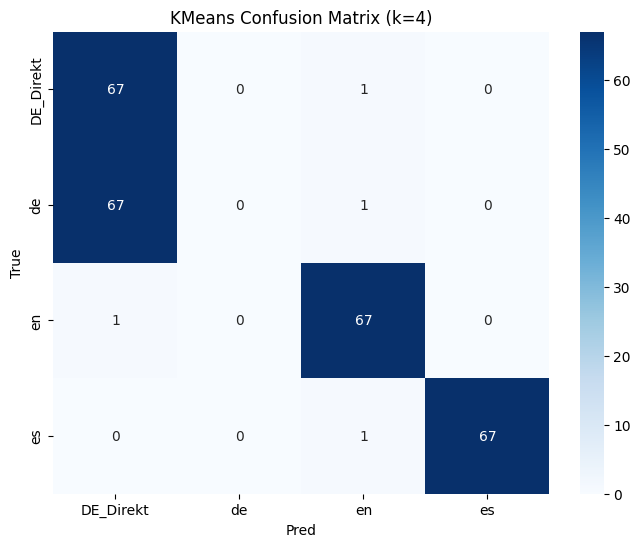

In [87]:
print(df["dataset_name"].value_counts())

min_count = df["dataset_name"].value_counts().min()

df, acc, cm = run_kmeans_evaluation(df, n_clusters=4, label_col='dataset_name', drop_cols=['dataset_name'], plot=True)

## NN

In [88]:
import scipy.sparse as sp
from sklearn.metrics import confusion_matrix



def run_nn(df, features, label_col="dataset_name", title="Neural Network"):


    X = df[features].values
    y = df[label_col].values

    if y.dtype.kind in {'O', 'U', 'S'}:  # string/object
        le = LabelEncoder()
        y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Length: {len(df)}, Train: {len(X_train)}, Test: {len(X_test)}")

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Ensure X is dense float64

    def to_dense_float(a):
        if sp.issparse(a):
            a = a.toarray()
        return np.asarray(a, dtype=np.float64)

    X_train_s = to_dense_float(X_train_s)
    X_test_s  = to_dense_float(X_test_s)


    # Ensure y is a plain 1D array (not sparse, not weird dtype)
    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)


    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)

    y_pred = mlp.predict(X_test_s)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    cm = confusion_matrix(y_test, y_pred)
    label_map = {i: cls for i, cls in enumerate(le.classes_)}  # Derived from actual data

    labels = sorted(label_map.keys())
    target_names = [label_map[i] for i in labels]

    print(
        "\nClassification Report:\n",
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            target_names=target_names,
            digits=4
        )
    )

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]

    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return mlp, accuracy, cm


### L2

Length: 272, Train: 217, Test: 55

===== MLP Classification of df =====
Test Accuracy: 0.6727272727272727

Classification Report:
               precision    recall  f1-score   support

   DE_Direkt     0.4483    0.9286    0.6047        14
          de     0.0000    0.0000    0.0000        13
          en     1.0000    0.7143    0.8333        14
          es     0.9333    1.0000    0.9655        14

    accuracy                         0.6727        55
   macro avg     0.5954    0.6607    0.6009        55
weighted avg     0.6062    0.6727    0.6118        55


Confusion matrix:
[[13  0  0  1]
 [13  0  0  0]
 [ 3  1 10  0]
 [ 0  0  0 14]]


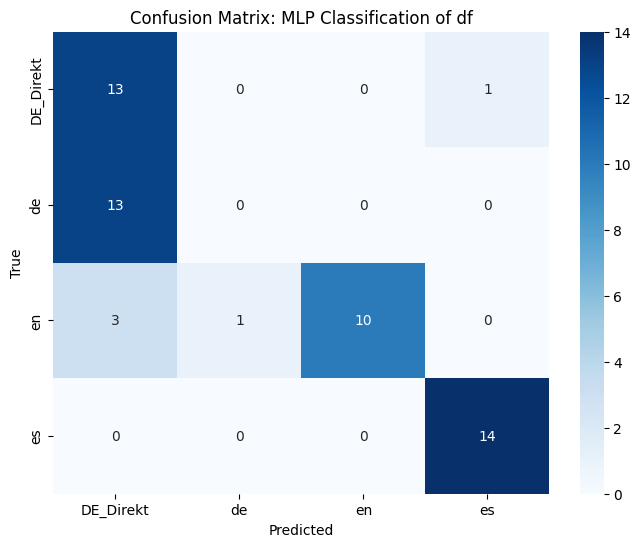

In [89]:
features = df.drop(columns=["dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(df, features, label_col="dataset_name", title="MLP Classification of df")

In [90]:
import os
 # Required packages
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def selectkbest_analysis(
    df,
    target_col='dataset_name',
    cols_to_drop=None,
    classes=None,
    k=10,
    output_dir='',
    zip_output=True
):

    DEFAULT_DROP = ['L1', 'dataset_name', 'cluster', 'kmeans_labels']
    all_to_drop  = list(set(DEFAULT_DROP + (cols_to_drop or [])))

    df_balanced  = df.copy().dropna()

    feature_cols = [c for c in df_balanced.columns if c not in all_to_drop]

    X_s          = df_balanced[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    y_balanced   = df_balanced[target_col].values

    # 1. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_s, y_balanced, stratify=y_balanced, random_state=42
    )

    # 2. Build class labels
    df_plot = df_balanced.copy()
    os.mkdir(output_dir)

    if 'dataset_name' in df_plot.columns:
        df_plot['class'] = (
            df_plot['dataset_name'].astype(str) + "_" +
            df_plot[target_col].astype(str)
        )
    else:
        df_plot['class'] = df_plot[target_col].astype(str)

    if classes is None:
        classes = sorted(df_plot['class'].unique().tolist())

    # 3. SelectKBest
    selector     = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_s, y_balanced)
    top_idx      = selector.get_support(indices=True)
    top_features = [feature_cols[i] for i in top_idx]

    print(f"[{output_dir}] Top {k} features by ANOVA F-test: {top_features}")

    # 4. Output directory
    os.makedirs(output_dir, exist_ok=True)

    for f in top_features:
        df_plot[f] = pd.to_numeric(df_plot[f], errors='coerce')

    # 5. Boxplots
    for feat in top_features:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.boxplot(x='class', y=feat, data=df_plot, order=classes, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f"{feat}_boxplot.png"), dpi=300)
        plt.close(fig)

    # 6. KDE plots
    for feat in top_features:
        fig, ax = plt.subplots(figsize=(8, 4))
        for cls in classes:
            subset = df_plot[df_plot['class'] == cls]
            if not subset.empty:
                sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)
        ax.set_title(f"KDE of {feat} by class")
        ax.set_xlabel(feat)
        ax.set_ylabel("Density")
        ax.legend()
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f"{feat}_KDE.png"), dpi=300)
        plt.close(fig)

    # 7. Feature importance bar chart
    f_scores = selector.scores_[top_idx]
    p_values = selector.pvalues_[top_idx]

    importance_df = pd.DataFrame({
        'Feature': top_features,
        'F_score': f_scores,
        'p_value': p_values
    }).sort_values(by='F_score', ascending=False)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x='F_score', y='Feature', data=importance_df, ax=ax)
    ax.set_xlabel("ANOVA F-score")
    ax.set_ylabel("Feature")
    ax.set_title(f"Feature Importance - SelectKBest: ({output_dir})")
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, "Top_Feature_Importance_desc.png"), dpi=300)
    plt.show()
    plt.close(fig)

    # 8. zip
    if zip_output:
        os.system(f"zip -r {output_dir}.zip {output_dir}")
        print(f"Saved → {output_dir}.zip")


    return importance_df, top_features

[Subtitles_analysis] Top 10 features by ANOVA F-test: ['indef', 'mquantif', 'mpred', 'infs', 'sconj', 'addit', 'numcls', 'simple', 'demdets', 'nnargs']


/tmp/ipykernel_4110/1208222348.py:86: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)
/tmp/ipykernel_4110/1208222348.py:86: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)
/tmp/ipykernel_4110/1208222348.py:86: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)
/tmp/ipykernel_4110/1208222348.py:86: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)


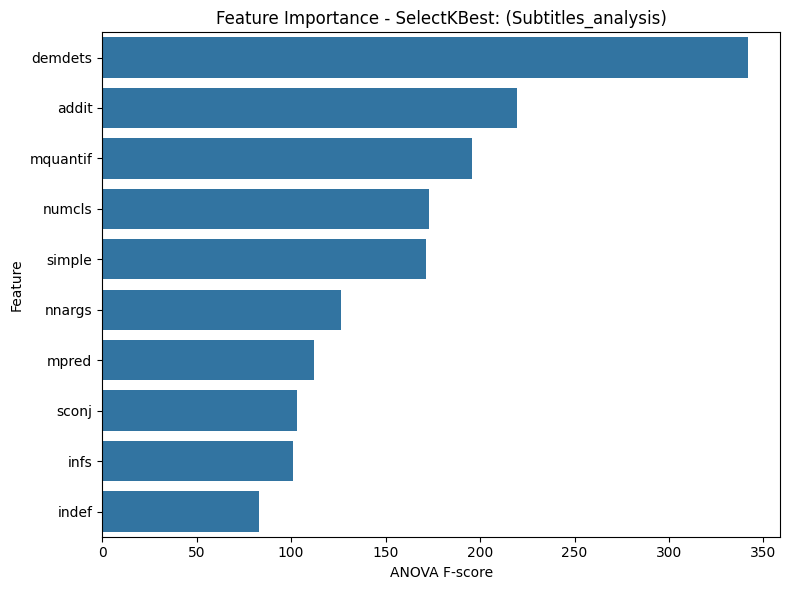

Saved → Subtitles_analysis.zip


(    Feature     F_score       p_value
 8   demdets  341.666941  3.041064e-91
 5     addit  219.370394  7.601419e-72
 1  mquantif  195.647241  3.363965e-67
 6    numcls  173.241313  1.921705e-62
 7    simple  171.264227  5.280712e-62
 9    nnargs  126.237767  5.455509e-51
 2     mpred  111.863195  5.516982e-47
 4     sconj  103.148982  2.044494e-44
 3      infs  101.188222  8.026540e-44
 0     indef   83.031230  5.153729e-38,
 ['indef',
  'mquantif',
  'mpred',
  'infs',
  'sconj',
  'addit',
  'numcls',
  'simple',
  'demdets',
  'nnargs'])

In [91]:
selectkbest_analysis(
    df,
    target_col='dataset_name',
    cols_to_drop=None,
    classes=None,
    k=10,
    output_dir="Subtitles_analysis",
    zip_output=True
)